# for ATLAS

- ATLAS数据进来时
  - 已经做完叶子节点合并
  - 节点属性很少，事件已经按照发生顺序排序

In [1]:
ObjectTypes = ['file','NetworkConnection']
SubjectTypes = ['process']
EventTypes = ['execute','read','fork','delete','write','EVENT_ACCEPT','EVENT_CONNECT','EVENT_GIVEINFO','EVENT_GETINFO']

# read 左边为file，右边为process  √
# fork 左边为process，右边为process
# delete 左边为process，右边为file
# write 左边为process，右边为file
# execute 左边为file，右边为process  √
# EVENT_ACCEPT 左边为NetworkConnection，右边为process
# EVENT_CONNECT 左边为process，右边为NetworkConnection
# EVENT_GIVEINFO 左边为process，右边为NetWorkConnection
# EVENT_GETINFO 左边为NetWorkConnection，右边为process


In [2]:
def get_active_actions_statements(lines): # （从ATLAS源码移植）该步骤能够对数据缩减造成什么影响？有什么意义？ 答：该函数旨在消除passive action，这些动作的客体在以目标进程为核心的连通子图构建过程中，没有被修改过，也没有主动执行过任何动作。但是这种方式会过滤掉恶意进程的read操作。可以修改一下，不过滤对关键位置敏感文件的读取动作。
    subjects = []
    subjects_statements = []
    # keyDict=["c:/windows/system32/config",]

    for statement in lines: # 加入进程
        #if not (statement.split()[1] == "read" or statement.split()[1] == "execute" or statement.split()[1] == "executed"):   # 在词形还原前只有网络访问操作有GIVEINFO和GETINFO
        if statement.split()[1] == "execute"  or statement.split()[1] == "read"  or statement.split()[1] == 'EVENT_ACCEPT' :# 代表信息流的传递？所以考虑与这两种动作相关的Object？  active actions与Passive action相对
            if not statement.split()[2] in subjects:
                subjects.append(statement.split()[2])
        elif statement.split()[1] == "write"  or statement.split()[1] == "delete" or statement.split()[1] == "EVENT_CONNECT" :# 代表信息流的传递？所以考虑与这两种动作相关的Object？  active actions与Passive action相对
            if not statement.split()[0] in subjects:
                subjects.append(statement.split()[0])
        elif statement.split()[1] == "fork":
            if not statement.split()[0] in subjects:
                subjects.append(statement.split()[0])
            if not statement.split()[2] in subjects:
                subjects.append(statement.split()[2])
    for statement in lines:# 加入非进程实体
        if statement.split()[1] == "write" or statement.split()[1] == "EVENT_CONNECT" or statement.split()[1] == 'EVENT_ACCEPT':
            if not statement.split()[2] in subjects:
                subjects.append(statement.split()[2])

    for statement in lines:
        if statement.split()[0] in subjects and statement.split()[2] in subjects:
            if not statement in subjects_statements:
                subjects_statements.append(statement)

    return subjects_statements, subjects

In [3]:
import networkx as nx
from tqdm import tqdm
# 不考虑GIVE_INFO和GET_INFO
# 将文本解析为图
FileName = 'seq_training_preprocessed_logs_M1-CVE-2015-5122_windows_h2'
with open('D:\\DataStorge\\IdeaOne\\TargetData\\ATLAS\\RawData\\{}.txt'.format(FileName),'r',encoding = 'utf-8') as f:
    lines = f.readlines()
    WantedLines, Subjects = get_active_actions_statements(lines)
Sequence = 1 # 事件起始序列
G = nx.MultiDiGraph()
for line in tqdm(WantedLines):
# for line in tqdm(lines):
    RawData = line.split()
    if RawData[1] == 'execute' or RawData[1] == 'read':
        G.add_node(RawData[0],type = 'file', name = RawData[0]) # 文件
        G.add_node(RawData[2],type = 'process', name = RawData[2]) # 进程
        G.add_edge(RawData[0],RawData[2],type = RawData[1], sequence = Sequence) # 执行
        Sequence += 1
    elif RawData[1] == 'fork':
        G.add_node(RawData[0],type = 'process', name = RawData[0]) # 父进程
        G.add_node(RawData[2],type = 'process', name = RawData[2]) # 子进程
        G.add_edge(RawData[0],RawData[2],type = 'fork', sequence = Sequence) # 分叉
        Sequence += 1
    elif RawData[1] == 'write' or RawData[1] == 'delete':
        G.add_node(RawData[0],type = 'process', name = RawData[0]) # 进程
        G.add_node(RawData[2],type = 'file', name = RawData[2]) # 文件
        G.add_edge(RawData[0],RawData[2],type = RawData[1], sequence = Sequence) # 写入
        Sequence += 1
    elif RawData[1] == 'EVENT_ACCEPT' :
        G.add_node(RawData[0],type = 'NetworkConnection', name = RawData[0]) # 连接
        G.add_node(RawData[2],type = 'process', name = RawData[2]) # 进程
        G.add_edge(RawData[0],RawData[2],type = RawData[1], sequence = Sequence) # 接受
        Sequence += 1
    elif RawData[1] == 'EVENT_CONNECT':
        G.add_node(RawData[0],type = 'process', name = RawData[0]) # 进程
        G.add_node(RawData[2],type = 'NetworkConnection', name = RawData[2]) # 连接
        G.add_edge(RawData[0],RawData[2],type = RawData[1], sequence = Sequence) # 连接
        Sequence += 1
        


100%|██████████| 629/629 [00:00<00:00, 297163.46it/s]


In [4]:
def showEdges(Graph,Node):
    for edge in list(Graph.in_edges(Node,data=True)) + list(Graph.out_edges(Node,data=True)):
    # G.remove_edge(edge[0],edge[1]
        print(edge)

In [5]:
# 针对数据集的修正
G.add_edge('c:/programfiles/mozillafirefox/firefox.exe_3548','192.168.223.3',type = 'EVENT_CONNECT', sequence = 470) # 起始节点
G.add_edge('c:/users/aalsahee/downloads/payload.exe','c:/windows/system32/svchost.exe_920',type = 'read',sequence = 500)
# G.remove_node('c:/windows/system32/csrss.exe_356')
# # # G.remove_node('c:/users/aalsahee/appdata/local/microsoft/windows/temporaryinternetfiles/counters.dat')

# ConcernedNode = 'c:/users/aalsahee/downloads/msf_2018_8174.rtf'

# showEdges(G,ConcernedNode)

0

In [6]:
showEdges(G,'c:/users/aalsahee/downloads/payload.exe')

('c:/programfiles/mozillafirefox/firefox.exe_3548', 'c:/users/aalsahee/downloads/payload.exe', {'type': 'write', 'sequence': 485})
('c:/users/aalsahee/downloads/payload.exe', 'c:/windows/system32/searchprotocolhost.exe_3656', {'type': 'read', 'sequence': 487})
('c:/users/aalsahee/downloads/payload.exe', 'c:/windows/explorer.exe_1764', {'type': 'read', 'sequence': 494})
('c:/users/aalsahee/downloads/payload.exe', 'c:/windows/explorer.exe_1764', {'type': 'execute', 'sequence': 501})
('c:/users/aalsahee/downloads/payload.exe', 'c:/windows/system32/svchost.exe_936', {'type': 'read', 'sequence': 495})
('c:/users/aalsahee/downloads/payload.exe', 'c:/windows/system32/svchost.exe_880', {'type': 'read', 'sequence': 504})
('c:/users/aalsahee/downloads/payload.exe', 'c:/windows/system32/svchost.exe_296', {'type': 'read', 'sequence': 509})
('c:/users/aalsahee/downloads/payload.exe', 'c:/windows/system32/werfault.exe_4080', {'type': 'read', 'sequence': 532})
('c:/users/aalsahee/downloads/payload.ex

In [7]:
# 提取与目标节点在信息流或控制流视角下满足单向联通条件的节点子图：确保子图节点之间最起码是单向可达的
	# 除此之外考虑记录进程Read操作（后续会化简）以还原完整攻击活动       
	# 如何构造算法消除可疑节点构造的差异，使得在同一子图中的可疑节点还原出来的子图是一致的？
		# 只有出边，没有入边的非进程节点 以及 只有入边,没有出边的节点（叶子节点）  为边界节点
			# 只有Process有传播控制流的权利，只有出边的Process不能视为边界节点，要做的是将其两条出边引出的系统活动算作子图的一部分。
		# 要考虑之前数据缩减工作和节点类型带来的边界节点：NetFlowObject就是一类边界节点
		# 子图是由边界节点划分开的，非边界节点会引入邻居进一步扩展子图规模
	# 节点扩展算法如何构建？
		# 异常节点为非Process：寻找其Process邻居节点，从Process开始构建
		# 异常节点为进程：
# 边缘节点判断
def  EdgeNodes(G,TargetNode):
	result = 0
	if len(list( G.predecessors(TargetNode))) == 0 and G.nodes[TargetNode]['type'] != 'process':# 非进程的无入边节点为边界节点  流起点
		# print(1)
		result = 1
	elif len(list( G.successors(TargetNode))) == 0 :# 无出边节点为边界节点  流终点
		# print(2)
		result = 1
	elif G.nodes[TargetNode]['type'] == 'NetworkConnection':# NetFlowObject为边界节点
		# print(3)
		result = 1
	return result



def construct_G_subgraph(G,Nodelist): # 默认Nodelist相互连通
	# global sub_nodes, node_set, G_subgraph, G
	ResultNodes=set() # 结果节点
	CandidateNode=set(Nodelist) # 候选节点
	while True:
		NetGenCanNode=set()

		for node in CandidateNode:	
			ResultNodes.add(node)
			if EdgeNodes(G,node)==0:# 非边缘节点,将其邻居加入遍历序列
				# print(node)
				successors = G.successors(node) # or neighbors
				predecessors = G.predecessors(node)
				NetGenCanNode=NetGenCanNode.union(successors)
				NetGenCanNode=NetGenCanNode.union(predecessors)
		CandidateNode=NetGenCanNode - ResultNodes # 取差集，否则无限循环
		print(len(CandidateNode))
		if len(CandidateNode)==0:
			break
	G_subgraph = G.subgraph(ResultNodes).copy()# 子图包含指定的节点及其之间的边，不涉及其他节点
	return  G_subgraph
			

	



In [8]:
AnchorNodes=["c:/users/aalsahee/downloads/payload.exe"]
# a=sorted(G.edges(data=True),key=lambda x:x[2]['Sequence']len()))
SubGraph=construct_G_subgraph(G,AnchorNodes)
# final,Nodelist = get_active_actions_statements(SubGraph)

8
93
88
114
31
5
0


In [9]:
# 排除噪声节点的影响。

FileType = ['file']
NoNeedNode=[]
MatchChar= ['appdata/local/mozilla/firefox','/appdata/roaming/mozilla/firefox/profiles']
for node in SubGraph:
    if SubGraph.nodes[node]['type'] in FileType and SubGraph.nodes[node]['name']:
        for MChar in MatchChar:
            if MChar in SubGraph.nodes[node]['name']:
                NoNeedNode.append(node)
                break
print(NoNeedNode)

SubGraph.remove_nodes_from(NoNeedNode) 

['c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2', 'c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/doomed', 'c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/safebrowsing/test-flash-simple.sbstore;c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/af3d286772c601b77184df2dda8ed91d1624dfdf;c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/index;c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/safebrowsing/testexcept-flashallow-simple.pset;c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/a8cccd0cdcd8b3aa763eb678682c1fa1bf2061d9;c:/users/aalsahee/appdata/roaming/mozilla/firefox/profiles/a6gl280b.default/places.sqlite;c:/users/aalsahee/appdata/local/mozilla/firefox/profiles/a6gl280b.default/cache2/entries/0517a029d3574d8e9dcc72785cb3fcef43edc3c0;c:/users/aalsahee/appd

# 数据缩减：移除无用信息中间节点，移除公共信息源与目的节点

In [10]:
# 信息源节点 先去掉只与Read\MMAP\LoadLibrary相关的基础信息节点
DeleteType=['read']
FileType = ['file']
NodeForRemoved=[]
Indector = 10 # 超过此数值为基础信息节点
for node in tqdm(SubGraph.nodes):
    if len(list(SubGraph.predecessors(node))) == 0 and SubGraph.nodes[node]['type'] in FileType: # 只有出边的文件实体
        # print(node)
        if len(list(SubGraph.successors(node))) >= Indector: # 出边数量大于Indector才纳入考虑范围
            NodeForRemoved.append(node)
            for edge in SubGraph.out_edges(node,data=True):
                if edge[2]['type'] not in DeleteType:
                    print(edge[2]['type'])
                    NodeForRemoved.remove(node)
                    break   
print(NodeForRemoved)
SubGraph.remove_nodes_from(NodeForRemoved)



100%|██████████| 334/334 [00:00<?, ?it/s]

[]


In [11]:
# 公共信息流向删除

DeleteType=['write']
NodeForRemoved=[]
Indector = 10 # 超过此数值为基础信息节点
for node in tqdm(SubGraph.nodes):
    if len(list(SubGraph.successors(node))) == 0 and SubGraph.nodes[node]['type'] in FileType: # 只有入边的文件实体
        # print(node)
        if len(list(SubGraph.predecessors(node))) >= Indector: # 出边数量大于Indector才纳入考虑范围
            NodeForRemoved.append(node)
            for edge in SubGraph.in_edges(node,data=True):
                if edge[2]['type'] not in DeleteType:
                    print(edge[2]['type'])
                    NodeForRemoved.remove(node)
                    break   
print(NodeForRemoved)
SubGraph.remove_nodes_from(NodeForRemoved)

100%|██████████| 334/334 [00:00<00:00, 221906.79it/s]

[]


In [12]:
import pickle
with open("D:\\DataStorge\\IdeaOne\\TargetData\\ATLAS\\MiddleData\\{}_Subgraph.data".format(FileName),'wb') as f:
    pickle.dump(SubGraph,f)

# 数据缩减：叶子节点合并（read\Write）

# 序列提取

- 0.错误信息流向纠正（删除干扰节点）
- 1.依据可疑节点确定信息源和信息终点的暴露节点
- 2.依据确定的源和终点还原信息流中关键节点
- 3.长链进程缩减
- 4.依据关键节点补充细节信息（如额外的信息流）

In [13]:
import pickle
import networkx as nx
from tqdm import tqdm
import os
with open("D:\\DataStorge\\IdeaOne\\TargetData\\ATLAS\\MiddleData\\{}_Subgraph.data".format(FileName),'rb') as f:
    SubGraph = pickle.load(f)

In [14]:
import copy
TargetNode=AnchorNodes[0]

NetType=['NetworkConnection']
NetNode=set()
DeleteNetNode = set()
NANetNode=set()
for node in SubGraph.nodes: # 找到互联网节点
    if SubGraph.nodes[node]['type'] in NetType  :
        DeleteNetNode.add(node)
        if  SubGraph.nodes[node]['name'] != '-_0':
            NetNode.add(node)
        else:
            NANetNode.add(node)
# print(NetNode)
# 互联网节点的邻居节点为暴露节点
# NetNode = ['192.168.223.3']
ExposureNode=[]
for node in NetNode:
    ExposureNode.extend(list(SubGraph.predecessors(node)) + list(SubGraph.successors(node)))
# print(set(ExposureNode))
# 互联网节点不能作为信息传输中间节点。


In [15]:
set(ExposureNode)

{'c:/programfiles/mozillafirefox/firefox.exe_3548',
 'c:/users/aalsahee/downloads/payload.exe_3800',
 'c:/windows/system32/svchost.exe_1164',
 'c:/windows/system32/svchost.exe_1180',
 'c:/windows/system32/svchost.exe_912'}

In [16]:
SearchGraph = copy.deepcopy(SubGraph)
SearchGraph.remove_nodes_from(DeleteNetNode)
SubGraph.remove_nodes_from(NANetNode)  # 过滤无用网络连接节点
# 移除DELETE的尝试
RemoveEdge=[]
for edge in tqdm(SearchGraph.edges(data=True)):
    if edge[2]['type'] == 'delete':
        # print(edge)
        RemoveEdge.append((edge[0],edge[1]))
for Item in RemoveEdge:
    SearchGraph.remove_edge(Item[0],Item[1])
print(len(RemoveEdge))
   

100%|██████████| 495/495 [00:00<00:00, 495035.88it/s]

14


In [17]:
def GetMarkSequence(SubGraph,SrcNode):
    MarkSequence = 9999999  # 第一次暴露时间
    for edge in list(SubGraph.in_edges(SrcNode,data=True)) + list(SubGraph.out_edges(SrcNode,data=True)): # 涉及到NetFlowObject，使用SubGraph
        if SubGraph.nodes[edge[1]]['type'] == 'NetworkConnection' or SubGraph.nodes[edge[0]]['type'] == 'NetworkConnection':
            # print(edge)
            if edge[2]['sequence'] < MarkSequence:
                MarkSequence = edge[2]['sequence']
    print(SrcNode,' + MarkSequence:',MarkSequence)
    return MarkSequence

In [18]:
# 检测两个节点之间是否存在时序合理的信息通路，若存在则返回通路，不存在则返回None，我们只考虑最短路径。
# 加入对暴露节点的特殊考核。
def PathDetect(Graph,SrcNode,DstNode):
    TestGraph=copy.deepcopy(Graph) # 创建新图表
    Result = None
    while nx.has_path(TestGraph,SrcNode,DstNode):
        path = list(nx.shortest_path(TestGraph,SrcNode,DstNode)) # 我们认为最短路径就能够代表信息传输动作，不需要还原所有的信息通路
        i = 0
        Next = 0 # 获取第一个暴露节点的网络访问时间
        Sign = 0
        while i+1 <= len(path)-1: # 基于时序判断 路径的合理性
            # print(dict(SearchGraph[path[i]][path[i+1]])[0]['type'],dict(SearchGraph[path[i]][path[i+1]])[0]['Sequence'])
            if Next<=dict(SearchGraph[path[i]][path[i+1]])[0]['sequence']:
                Next=dict(SearchGraph[path[i]][path[i+1]])[0]['sequence']
                i += 1
            else:
                RemovedPath = (path[i],path[i+1])
                # i+=1
                Sign = 1
                break
        if Sign == 0:
            Result = path
            break
        else:
            TestGraph.remove_edge(RemovedPath[0],RemovedPath[1])
    return Result
            

In [19]:
# 筛选与目标节点有信息流的暴露节点
BackConnectionNode=[] # 可疑节点上游信息源
ForwardConnectionNode=[] # 可疑节点下游信息终点
# test2=[]
for node in set(ExposureNode):
    if nx.has_path(SearchGraph,node,TargetNode) or node == TargetNode:
        BackConnectionNode.append(node)
#     if nx.has_path(SubGraph,node,TargetNode) or node == TargetNode:
#         test2.append(node)
    if nx.has_path(SearchGraph,TargetNode,node) or node == TargetNode:
        ForwardConnectionNode.append(node)

ConnectionNode = set(BackConnectionNode + ForwardConnectionNode)
# print(ConnectionNode)
BackConnectionNode = set(BackConnectionNode)
ForwardConnectionNode = set(ForwardConnectionNode)
print(BackConnectionNode)
print(ForwardConnectionNode)

{'c:/windows/system32/svchost.exe_912', 'c:/users/aalsahee/downloads/payload.exe_3800', 'c:/programfiles/mozillafirefox/firefox.exe_3548'}
{'c:/windows/system32/svchost.exe_912', 'c:/users/aalsahee/downloads/payload.exe_3800', 'c:/programfiles/mozillafirefox/firefox.exe_3548'}


In [20]:
# 在这一步确定所有信息传播路径都是符合时序的。
# 考虑多个信息源节点和信息终点存在的可能性。
# 在取交集之前要先排除长链进程的影响。

def LongestPath(Result):
    Max = 0
    Maxpath=[]
    for path in Result:
        if len(path) > Max:
            Max = len(path)
            Maxpath = path
    return Maxpath

def Contain(Lista,LongestList):
    removed = []
    for item in Lista:
        if item in LongestList:
            removed.append(item)
    if len(Lista) == len(removed):
        return True # 包含
    else:
        return False # 不包含

BackResult = []
ForwardResult = []

for node in BackConnectionNode: # 还原信息传播路径
# for node in test:
    result = PathDetect(SearchGraph,node,TargetNode)
    if result:
        print(result)
        BackResult.append(result)
print('------------------------------***********-------------------------------')
for node in ForwardConnectionNode:
    result = PathDetect(SearchGraph,TargetNode,node)
    if result:
        print(result)
        ForwardResult.append(result)


SrcNodes = [] # 可以存在复数个信息源节点
# 源节点筛选：源节点连接网络的时间应该早于信息后向传递的时间
for path in BackResult:
    if len(path)>1:
        # print(path)
        FirstNetSeq = GetMarkSequence(SubGraph,path[0])
        # print(FirstNetSeq)
        if FirstNetSeq > dict(SearchGraph[path[0]][path[1]])[0]['sequence']: # 我们只关注发生在互联网连接之后的信息传递事件
            print('removedPath:',path,dict(SearchGraph[path[0]][path[1]])[0]['sequence'])
            BackResult.remove(path)
            # 如果该条最短路径不符合要求就重新计算一条，直到两点之间不联通或存在符合要求的最短路径为止。
            SearchGraph.remove_edge(path[0],path[1])
            result= PathDetect(SearchGraph,path[0],TargetNode)
            if result:
                print(result)
                if result not in BackResult:
                    BackResult.append(result)
            

print('------------------------------***********-------------------------------')
# 取并集
MaxBackpath = LongestPath(BackResult)
# print('MaxPath',MaxBackpath)
for path in BackResult:
    print(path)
    if path == MaxBackpath:
        continue
    if Contain(path,MaxBackpath):
        BackResult.remove(path)
        # print(path)
for path in BackResult:
    print(path)
    SrcNodes.append(path[0])

print(BackResult)
print(SrcNodes)

print('------------------------------***********-------------------------------')
DstNodes = [] # 可以存在复数个信息终点节点
# DetectPath保证路径的时序合理性，后续的ForwardTracking也有时序做判断依据，在此不需要对时序做额外判断
# 取并集
MaxForwardpath = LongestPath(ForwardResult)
for path in ForwardResult:
    if path == MaxForwardpath:
        continue
    if Contain(path,MaxForwardpath):
        ForwardResult.remove(path)
        # print(path)
for path in ForwardResult:
    DstNodes.append(path[-1])

print(ForwardResult)
print(DstNodes)

['c:/programfiles/mozillafirefox/firefox.exe_3548', 'c:/users/aalsahee/downloads/payload.exe']
------------------------------***********-------------------------------
['c:/users/aalsahee/downloads/payload.exe', 'c:/windows/system32/svchost.exe_920', 'c:/users/aalsahee/downloads/payload.exe_3800']
c:/programfiles/mozillafirefox/firefox.exe_3548  + MarkSequence: 251
------------------------------***********-------------------------------
['c:/programfiles/mozillafirefox/firefox.exe_3548', 'c:/users/aalsahee/downloads/payload.exe']
['c:/programfiles/mozillafirefox/firefox.exe_3548', 'c:/users/aalsahee/downloads/payload.exe']
[['c:/programfiles/mozillafirefox/firefox.exe_3548', 'c:/users/aalsahee/downloads/payload.exe']]
['c:/programfiles/mozillafirefox/firefox.exe_3548']
------------------------------***********-------------------------------
[['c:/users/aalsahee/downloads/payload.exe', 'c:/windows/system32/svchost.exe_920', 'c:/users/aalsahee/downloads/payload.exe_3800']]
['c:/users/aal

In [21]:
# 起始的关键节点一定是进程，在攻击活动中一定处于骨干地位。优先选取信息流入的进程。
# 基于时序的信息流还原，由于是从该信息源头进行信息流还原，因此还原过程是单向的。
# 再还原后的节点中发现‘关键节点’：直接参与信息流通的节点
# 基于筛选出的关键节点再做针对‘获取信息’操作的补充：基于信息源和信息终点确定关键节点筛选方法。
# SearchGraph移除了NetFlowObject、tty文件、DELETE操作这些会影响信息流还原的干扰因素
def GetKeyNodes(SearchGraph,SubGraph,SrcNode,DstNode):
# 获取关键节点
    ResultNode=set()
    NextNode = set([SrcNode]) # 每轮循环的起点，从信息源起点开始遍历到信息终点
    MarkSequence = GetMarkSequence(SubGraph,SrcNode) # 获取信息源连接互联网的时间
    print(MarkSequence)
    while True:
        # i += 1 
        NextCandi=set()
        for node in NextNode:
            # print(node)
            if PathDetect(SearchGraph,node,DstNode) and PathDetect(SearchGraph,SrcNode,node):  # 使用信息源和信息终点确定关键节点
                print(node)
                ResultNode.add(node)
                for edge in SearchGraph.out_edges(node,data=True): # 遍历关键节点出边
                    print(edge)
                    if edge[2]['sequence'] - MarkSequence > -2: # 检查时序
                        if SearchGraph.out_degree(edge[1]) == 0 and edge[1] not in ConnectionNode: # 查询出度,排除掉暴露节点特殊情况（出度为1，但出边为连接互联网，但互联网节点被删除）
                            # ResultNode.add(edge[1]) # 边缘节点与Target无直接关联，在捕获关键节点时不考虑，再后续恢复完整信息流时再处理。
                            
                            pass
                        else:
                            NextCandi.add(edge[1])
        if len(NextCandi) == 0:
            break
        else:
            print(len(NextCandi))
            print(NextCandi)
            NextNode = NextCandi - ResultNode # 考虑循环情况
    print(ResultNode)
    return ResultNode

        

In [22]:
FinalResultNode = set()
for Src in SrcNodes: # 所有源节点和目的节点配对，发现关键节点。
    for Dst in DstNodes:
        FinalResultNode = FinalResultNode.union(GetKeyNodes(SearchGraph,SubGraph,Src,Dst))

c:/programfiles/mozillafirefox/firefox.exe_3548  + MarkSequence: 251
251
c:/programfiles/mozillafirefox/firefox.exe_3548
('c:/programfiles/mozillafirefox/firefox.exe_3548', 'c:/programfiles/mozillafirefox/firefox.exe_3828', {'type': 'fork', 'sequence': 246})
('c:/programfiles/mozillafirefox/firefox.exe_3548', 'c:/users/aalsahee/appdata/local/microsoft/windows/temporaryinternetfiles/counters.dat', {'type': 'write', 'sequence': 247})
('c:/programfiles/mozillafirefox/firefox.exe_3548', 'c:/users/aalsahee/appdata/local/temp/log.txt-main.3548;c:/users/aalsahee/desktop/logs/log.txt-main.3548', {'type': 'write', 'sequence': 302})
('c:/programfiles/mozillafirefox/firefox.exe_3548', 'c:/users/aalsahee/downloads', {'type': 'write', 'sequence': 484})
('c:/programfiles/mozillafirefox/firefox.exe_3548', 'c:/users/aalsahee/downloads/payload.exe', {'type': 'write', 'sequence': 485})
('c:/programfiles/mozillafirefox/firefox.exe_3548', 'c:/users/aalsahee/downloads/payload.exe:zone.identifier', {'type':

In [23]:
len(FinalResultNode)
FinalResultNode

{'c:/$recycle.bin/s-1-5-21-450080267-1945256726-3465656282-1000',
 'c:/$recycle.bin/s-1-5-21-450080267-1945256726-3465656282-1000/$i94yos0.3548;c:/users/aalsahee/appdata/roaming/microsoft/windows/recent/automaticdestinations/1b4dd67f29cb1962.automaticdestinations-ms;c:/users/aalsahee/appdata/roaming/microsoft/windows/recent/automaticdestinations/918e0ecb43d17e23.automaticdestinations-ms;c:/users/aalsahee/appdata/roaming/microsoft/windows/recent/automaticdestinations/7e4dca80246863e3.automaticdestinations-ms',
 'c:/programfiles/mozillafirefox/firefox.exe_3548',
 'c:/users/aalsahee/appdata/local/microsoft/windows/temporaryinternetfiles/counters.dat',
 'c:/users/aalsahee/appdata/local/temp/cab1620.tmp',
 'c:/users/aalsahee/appdata/local/temp/tar16b1.tmp;c:/users/aalsahee/appdata/local/temp/cab1631.tmp;c:/users/aalsahee/appdata/local/temp/cab16b0.tmp;c:/users/aalsahee/appdata/locallow/microsoft/cryptneturlcache/metadata/94308059b57b3142e455b38a6eb92015;c:/users/aalsahee/appdata/local/temp/

In [24]:
# 补充信息流活动细节（中间节点的文件读取和网络连接）,查询节点入边，考虑Sequence
# InOperation=['EVENT_READ','EVENT_EXECUTE','EVENT_MMAP','EVENT_FORK','EVENT_CLONE','EVENT_UNIT']
# OutOperation=['EVENT_WRITE','EVENT_FORK','EVENT_CLONE','EVENT_UNIT']
# NetObject = 'NetFlowObject'
MarkSequence  = GetMarkSequence(SubGraph,SrcNodes[0])
# 补充信息传播路径信息
AddedNodes = set()
for node in FinalResultNode: 
    # 互联网节点
    for edge in SubGraph.out_edges(node,data=True): # 在SubGraph上获取信息
        if edge[2]['sequence'] > MarkSequence : # 检验时序
            if (SubGraph.nodes[edge[1]]['type'] != 'process') or (edge[1] in ConnectionNode):# 不考虑信息流方向不同的进程路径。
                print(edge)
                AddedNodes.add(edge[1]) 
    # 互联网节点 + 文件节点、进程节点（此时只考虑直系父亲节点，不做追溯，因为默认其与可疑节点信息源无关）
    for edge in SubGraph.in_edges(node,data=True): # 在SubGraph上获取信息
        if edge[2]['sequence'] > MarkSequence : # 检验时序
            if SubGraph.nodes[edge[0]]['type'] != 'process':
                AddedNodes.add(edge[0])




c:/programfiles/mozillafirefox/firefox.exe_3548  + MarkSequence: 251
('c:/users/aalsahee/appdata/local/microsoft/windows/temporaryinternetfiles/counters.dat', 'c:/users/aalsahee/downloads/payload.exe_3800', {'type': 'read', 'sequence': 503})
('c:/users/aalsahee/downloads/payload.exe_3800', 'c:/users/aalsahee/appdata/local/microsoft/windows/temporaryinternetfiles/counters.dat', {'type': 'write', 'sequence': 507})
('c:/users/aalsahee/downloads/payload.exe_3800', '192.168.223.3', {'type': 'EVENT_CONNECT', 'sequence': 512})
('c:/users/aalsahee/downloads/payload.exe_3800', 'c:/users/aalsahee/appdata/local/temp/cab1620.tmp', {'type': 'write', 'sequence': 513})
('c:/users/aalsahee/downloads/payload.exe_3800', 'c:/users/aalsahee/appdata/local/temp/cab1620.tmp', {'type': 'delete', 'sequence': 514})
('c:/users/aalsahee/downloads/payload.exe_3800', '8.249.107.254', {'type': 'EVENT_CONNECT', 'sequence': 515})
('c:/users/aalsahee/downloads/payload.exe_3800', 'c:/users/aalsahee/appdata/local/temp/ta

In [25]:
import matplotlib
import matplotlib.pyplot as plt
ResultNode = FinalResultNode.union(AddedNodes)
print(len(ResultNode))
print(ResultNode)
count = 0
for node in ResultNode:
    if SubGraph.nodes[node]['type'] == 'NetworkConnection':
        count += 1
print(count)

TestGraph = SubGraph.subgraph(ResultNode)





55
{'172.217.9.67', 'c:/windows/system32/dllhost.exe_3784', '192.168.223.3', 'c:/users/aalsahee/downloads/payload.exe', '34.214.252.85', '172.217.4.78', 'c:/users/aalsahee/appdata/local/temp/ndf4d65.tmp', '172.217.1.46', '172.217.5.14', '34.218.27.98', '172.217.9.34', '149.165.180.17', 'c:/users/aalsahee/appdata/local/microsoft/windows/temporaryinternetfiles/counters.dat', 'c:/users/aalsahee/downloads/payload.exe_3800', '52.85.117.14', 'c:/windows/system32/svchost.exe_936', 'c:/$recycle.bin/s-1-5-21-450080267-1945256726-3465656282-1000/$i94yos0.3548;c:/users/aalsahee/appdata/roaming/microsoft/windows/recent/automaticdestinations/1b4dd67f29cb1962.automaticdestinations-ms;c:/users/aalsahee/appdata/roaming/microsoft/windows/recent/automaticdestinations/918e0ecb43d17e23.automaticdestinations-ms;c:/users/aalsahee/appdata/roaming/microsoft/windows/recent/automaticdestinations/7e4dca80246863e3.automaticdestinations-ms', '172.217.8.173', 'c:/users/aalsahee/appdata/local/diagnostics/460911090/2

In [26]:
count = 0
for node in ResultNode:
    if SubGraph.nodes[node]['type'] == 'NetworkConnection':
        count += 1
print(count)

33


In [27]:
for node in TestGraph.nodes(data=True):
    print(str(node),TestGraph.out_degree(node[0]))

('c:/users/aalsahee/appdata/local/microsoft/nettraces', {'type': 'file', 'name': 'c:/users/aalsahee/appdata/local/microsoft/nettraces'}) 1
('172.217.9.46', {'type': 'NetworkConnection', 'name': '172.217.9.46'}) 0
('172.217.9.67', {'type': 'NetworkConnection', 'name': '172.217.9.67'}) 0
('52.89.32.107', {'type': 'NetworkConnection', 'name': '52.89.32.107'}) 0
('c:/users/aalsahee/downloads/payload.exe:zone.identifier', {'type': 'file', 'name': 'c:/users/aalsahee/downloads/payload.exe:zone.identifier'}) 1
('c:/windows/system32/svchost.exe_920', {'type': 'process', 'name': 'c:/windows/system32/svchost.exe_920'}) 1
('52.10.161.248', {'type': 'NetworkConnection', 'name': '52.10.161.248'}) 0
('c:/windows/system32/dllhost.exe_3784', {'type': 'process', 'name': 'c:/windows/system32/dllhost.exe_3784'}) 1
('c:/users/aalsahee/appdata/local/temp/cab1620.tmp', {'type': 'file', 'name': 'c:/users/aalsahee/appdata/local/temp/cab1620.tmp'}) 1
('172.217.0.2', {'type': 'NetworkConnection', 'name': '172.21

In [28]:

Merged={} # key:(Process,EventType)  value:[node1,node2,.....]

CandidateNode=[]

RemovedNodes=[]
for node in TestGraph.nodes:
    if len(list(TestGraph.successors(node))) == 0 and len(list(TestGraph.predecessors(node))) == 1 and TestGraph.nodes[node]['type'] == 'NetworkConnection':  # 找到所有同类型孤立节点:类型为文件、无出边，只有一条入边
        CandidateNode.append(node)
print(len(CandidateNode))
for node in CandidateNode:
    # print(node)
    # print(list(SubGraph.in_edges(node,data=True)))
    Edge=list(TestGraph.in_edges(node,data=True))[0] #获取边信息
    if (Edge[0],Edge[2]['type']) not in Merged:
        Merged[(Edge[0],Edge[2]['type'])] = [node]
    else:
        Merged[(Edge[0],Edge[2]['type'])].append(node)
print(Merged)
for Item in Merged:
    if len(Merged[Item]) > 1:
        MergedPath=''
        MergedSequence=9999999
        for node in Merged[Item]:
            Edge=list(SubGraph.in_edges(node,data=True))[0]
            if Edge[2]['sequence']<MergedSequence: # 事件序列
                MergedSequence=Edge[2]['sequence']
            if SubGraph.nodes[node]['name'] != None:  # 节点属性
                MergedPath += ';' + SubGraph.nodes[node]['name']
        RemovedNodes=Merged[Item][1:] # 选取第一个节点为合并节点
        SubGraph.nodes[Merged[Item][0]]['name'] = MergedPath # 修改节点属性

        OldEdge=list(SubGraph.in_edges(Merged[Item][0],data=True))[0] # 获取旧边
        SubGraph.remove_edge(OldEdge[0],OldEdge[1])# 删除旧边

        SubGraph.add_edge(Item[0],Merged[Item][0],type=Item[1],sequence=MergedSequence) # 添加新边
        SubGraph.remove_nodes_from(RemovedNodes) # 移除其余节点
        print(RemovedNodes)


32
{('c:/programfiles/mozillafirefox/firefox.exe_3548', 'EVENT_CONNECT'): ['172.217.9.46', '172.217.9.67', '52.89.32.107', '52.10.161.248', '172.217.0.2', '34.214.252.85', '172.217.5.4', '172.217.4.78', '216.58.192.206', '172.217.1.46', '172.217.5.14', '172.217.9.34', '34.218.27.98', '149.165.180.17', '54.186.208.153', '172.217.0.1', '72.21.91.29', '54.230.88.144', '172.217.6.14', '52.85.117.14', '104.27.188.5', '216.58.192.131', '192.168.223.130', '54.187.144.104', '52.85.117.73', '172.217.8.173', '172.217.9.78', '52.35.247.242', '52.85.117.102', '52.85.113.13', '23.62.239.24'], ('c:/users/aalsahee/downloads/payload.exe_3800', 'EVENT_CONNECT'): ['8.249.107.254']}
['172.217.9.67', '52.89.32.107', '52.10.161.248', '172.217.0.2', '34.214.252.85', '172.217.5.4', '172.217.4.78', '216.58.192.206', '172.217.1.46', '172.217.5.14', '172.217.9.34', '34.218.27.98', '149.165.180.17', '54.186.208.153', '172.217.0.1', '72.21.91.29', '54.230.88.144', '172.217.6.14', '52.85.117.14', '104.27.188.5', '

In [29]:
Edgesssss=list(TestGraph.edges(data=True))

SortedEdge = Edgesssss.sort(key = lambda x:x[2]['sequence'])

for edge in Edgesssss:
    # if 'sequence' not in edge[2]:
    print(str(edge))
print(len(Edgesssss))

('c:/$recycle.bin/s-1-5-21-450080267-1945256726-3465656282-1000', 'c:/windows/explorer.exe_1764', {'type': 'read', 'sequence': 131})
('c:/users/aalsahee/appdata/local/temp', 'c:/windows/explorer.exe_1764', {'type': 'read', 'sequence': 155})
('c:/windows/explorer.exe_1764', 'c:/users/aalsahee/appdata/local/microsoft/windows/temporaryinternetfiles/counters.dat', {'type': 'write', 'sequence': 204})
('c:/users/aalsahee/appdata/local/microsoft/windows/temporaryinternetfiles/counters.dat', 'c:/windows/explorer.exe_1764', {'type': 'read', 'sequence': 205})
('c:/users/aalsahee/desktop/logs', 'c:/windows/explorer.exe_1764', {'type': 'read', 'sequence': 213})
('c:/windows/explorer.exe_1764', 'c:/programfiles/mozillafirefox/firefox.exe_3548', {'type': 'fork', 'sequence': 233})
('c:/users/aalsahee/appdata/local/microsoft/windows/temporaryinternetfiles/counters.dat', 'c:/programfiles/mozillafirefox/firefox.exe_3548', {'type': 'read', 'sequence': 245})
('c:/programfiles/mozillafirefox/firefox.exe_35

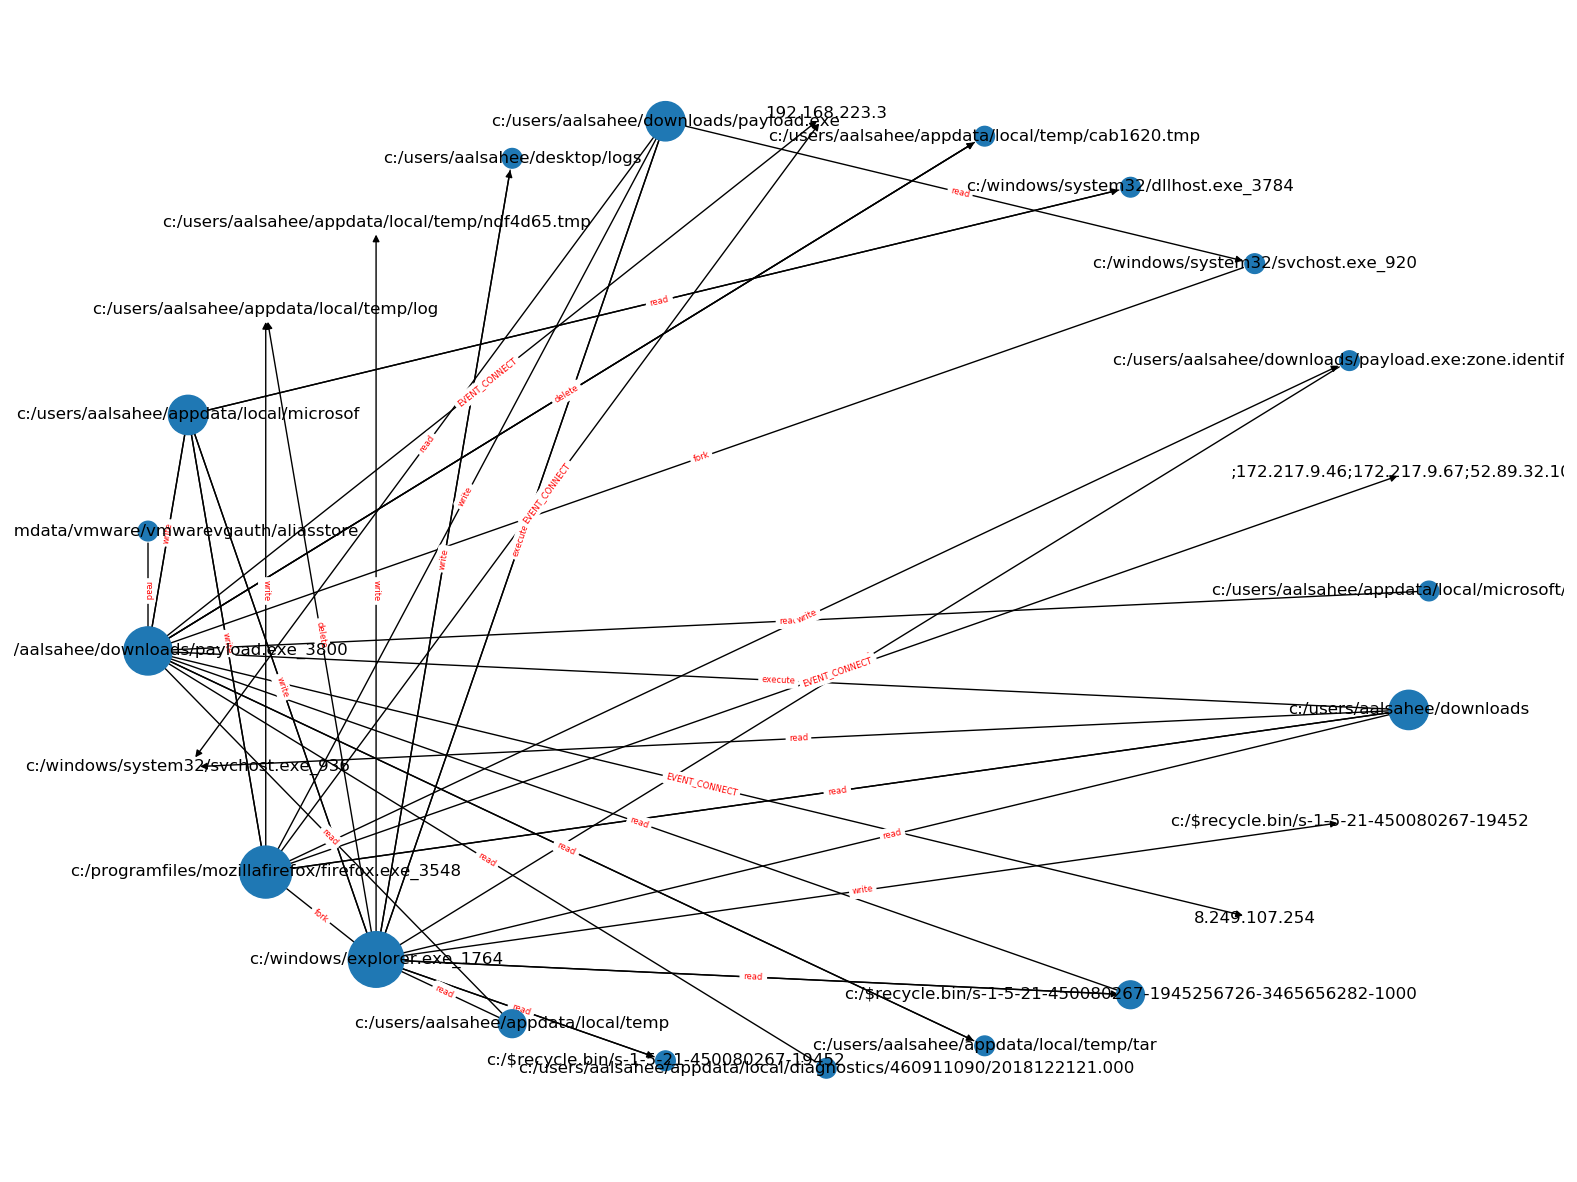

In [30]:
import numpy as np
nodeLabels = {}
for node in TestGraph.nodes:
    if len(TestGraph.nodes[node]['name'])<= 70:
        nodeLabels[node] = TestGraph.nodes[node]['name']
    else:
        nodeLabels[node] = TestGraph.nodes[node]['name'][:40]
EdgeLabels = {}
for edge in TestGraph.edges(data=True):
    EdgeLabels[(edge[0],edge[1])] = edge[2]['type']

weights = [TestGraph.out_degree(node) for node in TestGraph.nodes]

scaled_weights = np.array(weights) * 200

nodes_to_draw = TestGraph.nodes
edges_to_draw = TestGraph.edges
# pos = nx.spring_layout(TestGraph,k = 100)
pos = nx.circular_layout(TestGraph)
plt.figure(figsize=(20,15))
nx.draw_networkx_nodes(TestGraph, pos,node_size=scaled_weights,
                       nodelist=nodes_to_draw,)

# 画边
nx.draw_networkx_edges(TestGraph, pos,
                       edgelist=edges_to_draw,)

# 画标签
nx.draw_networkx_edge_labels(TestGraph, pos, edge_labels=EdgeLabels, font_color='red', font_size=6)
nx.draw_networkx_labels(TestGraph, pos, font_size=12, labels=nodeLabels,font_color='black') 
plt.axis("off")
plt.show()


In [31]:
import networkx as nx


# with open("D:\\DataStorge\\IdeaOne\\TargetData\\DarpaTC\\Cadets\\Reduced\\SubGraph_sk_db_bid_lll.data",'wb') as f:
#     pickle.dump(SubGraph,f)
a = [n for n in SubGraph.nodes if n not in TestGraph.nodes]
SubGraph.remove_nodes_from(a)

In [32]:
with open("D:\\DataStorge\\IdeaOne\\TargetData\\ATLAS\\FinalResult\\{}.data".format(FileName),'wb') as f:
    pickle.dump(SubGraph,f)